## EN3160 Assignment 2 on Fitting and Alignment

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Q1

In [24]:
#Import image
im =cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
assert im is not None

# Get normalized grayscale image
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY) / 255

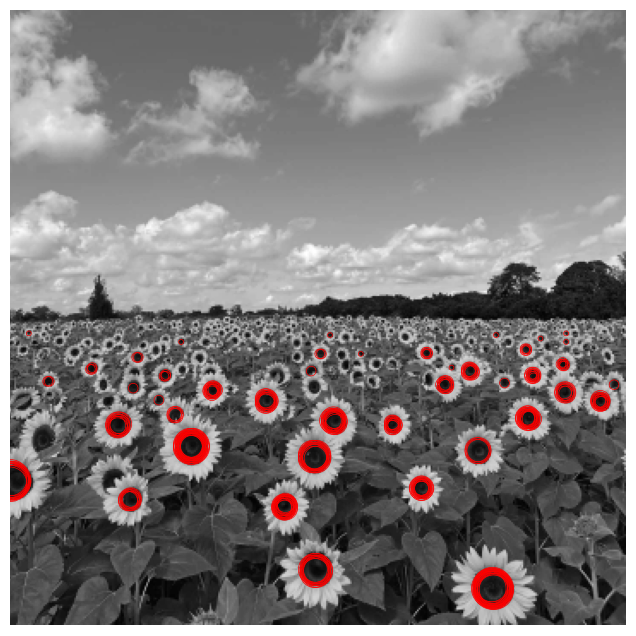

In [ ]:
# Plot the grayscale image
plt.figure(figsize=(8, 8), frameon=False)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Get the current axes object
ax = plt.gca()

# Range of Sigmas
sigmas = np.arange(1, 16, 1)

# Detect blobs at different sigmas
for sigma in sigmas:
    log_hw = 3*np.max(sigma)
    X, Y = np.meshgrid(np.arange(-log_hw, log_hw + 1, 1), np.arange(-log_hw, log_hw + 1, 1))

    # Get Laplacian of Gaussian
    log = (1/(2*np.pi*sigma**2)) * ((X**2 + Y**2 - 2*sigma**2) / sigma**4) * np.exp(-(X**2 + Y**2) / (2*sigma**2))
    
    # Scale Normalized Laplacian of Gaussian
    log = sigma**2 * log

    # Convolve image with LoG filter
    im_log = cv.filter2D(gray, -1, log)

    # Squared response to enhance blobs
    im_log = im_log**2

    coordinates = []
    h, w = im_log.shape
    # Threshold for maxima detection
    threshold = 0.1  
    # iterate over 3x3 sections of the image
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            slice_img = im_log[i - 1:i + 2, j - 1:j + 2]
            if np.max(slice_img) >= threshold:
                # Get coordinates of the maximum point
                x, y = np.unravel_index(slice_img.argmax(), slice_img.shape)
                coordinates.append((i - 1 + x, j - 1 + y))
    coordinates = set(coordinates)

    # Plot circles around detected blobs
    for x, y in coordinates:
        c = plt.Circle((y, x), sigma * 1.414, color='r', linewidth=0.5, fill=False)
        ax.add_patch(c)
    ax.plot()

ax.set_xlim([0, im.shape[1]])
ax.set_ylim([im.shape[0], 0])

plt.show()


In [ ]:

\
